<br/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="left"/>
<img src="images/skillnest-logo.png" alt="" width="200px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science - Módulo 1</h2><br/>
<h1>Inferencia Estadística</h1>
<br/><br/>
    <b>Instructor Principal:</b> Patricio Olivares polivares@skillnest.com <br/>
    <b>Instructor Asistente:</b> Cristian Sánchez csanchez@skillnest.com<br/><br/>
    <b>Skill Nest</b>

</div>

# Tipos de errores

Para determinar el correcto funcionamiento de un algoritmo de clasificación, podemos preguntarnos

- *¿Cuántas veces acertamos la clasificación de una clase y cuántas veces no?*

Los errores que puede cometer nuestro clasificador son de dos tipos:

## Errores de Tipo 1: Falso Positivo

Clasificamos un elemento como *perteneciente* (positivo) a la clase **incorrectamente** (falso)

<img src="images/un5.jpeg" alt="" width="300px" align="center"/>

## Errores de Tipo 2: Falso Negativo

Clasificamos un elemento como *no perteneciente* (negativo) a la clase **incorrectamente** (falso)

<img src="images/noUn5.jpeg" alt="" width="300px" align="center"/>

# Matriz de confusión

Permite contar la cantidad de veces que instancias de la clase A son clasificadas como clase B

<img src="images/matrizConfusion.png" alt="" width="700px" align="center"/>
Fuente: "Hands-on Machine Learning with Scikit-Learn, Keras & Tensorflow", O'Reilly

## Ejemplo

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# Primera vez que se importa la biblioteca de aprendizaje automático scikit-learn
# No te preocupes si esto parece mucho código
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ten en cuenta que es probable que el nombre del archivo sea diferente en tu computadora (especialmente más adelante en el curso)
filename = 'data/titanic.csv'
df = pd.read_csv(filename)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
# ESTO SE VERÁ EN DETALLE EN EL SIGUIENTE MÓDULO!!
# Transforma la columna Sexo en una forma que no sea de texto
# Elijo cuatro funciones, podrías haber elegido otras
feature_cols = ['Pclass', 'Parch', 'Age', 'Sex']
# Convierta la columna Sexo en algo que pueda alimentar a un modelo
# Tiene
df['Sex'] = df.Sex.map({'male': 0, 
                        'female': 1})
# Eliminar filas donde la edad es nan del conjunto de datos
df = df.loc[~df['Age'].isnull(), :]
# Crear matriz de características y vector objetivo
X = df.loc[:, feature_cols]
y = df['Survived']
# Divida los datos en conjuntos de prueba y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0)
# Estandarizar datos
scaler = StandardScaler()
# Ajusta solo en el conjunto de entrenamiento
scaler.fit(X_train)
# Aplicar transformación tanto al conjunto de entrenamiento como al conjunto de prueba
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
# Crea una instancia de un modelo
logreg = LogisticRegression()
# Entrena el modelo con los datos
logreg.fit(X_train, y_train);
# predicciones de clase (no probabilidades predichas)
predictions = logreg.predict(X_test)
print(predictions)
print(y_test.tolist())

[1 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 1 1
 1 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0
 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 1 0 0 1 0 1 1 0 0 0 1
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 1 0]
[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0]


In [13]:
# valores reales: y_test.values
# predicciones: predicciones del modelo
print("Total de elementos:", len(y_test.values))
cm = metrics.confusion_matrix(y_test.values, predictions)
print(cm)
print(cm.ravel()) # ravel() es una función que, a partir de una matriz de datos, me entrega los valores como si fuera una única lista
tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)

Total de elementos: 179
[[87 16]
 [17 59]]
[87 16 17 59]
87 16 17 59


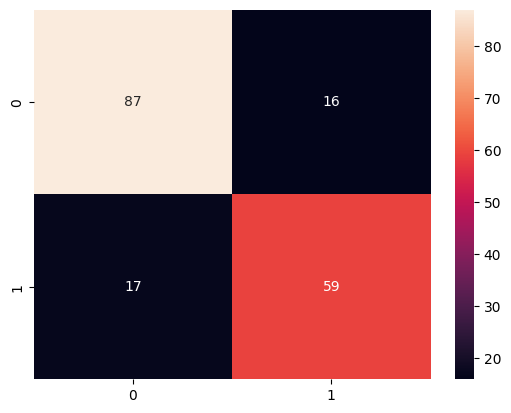

In [14]:
# Mostrando gráficamente la matriz de confusión
import seaborn as sns

f = sns.heatmap(cm, annot=True)

# Accuracy (exactitud)

- Fracción de casos correctamente clasificados sobre casos totales (¿Cuántas veces acerté?)

$$ \text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

- En nuestra matriz de confusión anterior, sería

$$\text{accuracy} = \frac{59+87}{59 + 87 + 16 + 17} = 0.8156 = 81.56\%$$

In [15]:
score = logreg.score(X_test, y_test) # Esta línea, para este modelo, calcula el accuracy
print("Score obtenido por Regresor", score)
manual_score = (tp + tn)/(tp + tn + fp + fn)
print("Score obtenido manualmente", manual_score)

Score obtenido por Regresor 0.8156424581005587
Score obtenido manualmente 0.8156424581005587


In [22]:
# Ej. Modelo de clasificación de 5s
import numpy as np
datos = [1,2,1,3,4,2,5,3,4,6,5,4,2,7,9,8,9,6,4,5]
valores_reales = [0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1]

# Creando el modelo "Nada es 5"
# Emularemos las predicciones de este modelo que clasifica todo como
# "No 5" en la siguiente variable
predicciones = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0] # Crea una lista de 0s
print(predicciones)
print(valores_reales)
# # Nuestro modelo clasifica todo como NO 5
tn=17 # 17 son los números que no eran 5, por lo tanto nuestro modelo los clasifico bien
tp=0 # Como no clasificamos ningún 5, los TP son
fn=3 # Los 5s que clasificamos incorrectamente, están acá
fp=0 # No hicimos ninguna clasificación FP.

accuracy = (tn+tp)/(tn+tp+fn+fp)
print(accuracy*100)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
85.0


In [17]:
# Ej. Modelo de clasificación de 5s
import numpy as np
datos = [1,2,1,3,4,2,5,5,5,5,5,5,5,5,8,5,5,5,5,5]
valores_reales = [0,0,0,0,0,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1]

# Este sería el modelo contrario, clasifica "Todo como 5"
predicciones = np.ones(20) # Crea una lista de 0s
print(predicciones)
print(valores_reales)
# Nuestro modelo clasifica todo como NO 5
tn=0 # 17 son los números que no eran 5, por lo tanto nuestro modelo los clasifico bien
tp=14 # Como no clasificamos ningún 5, los TP son
fn=0 # Los 5s que clasificamos incorrectamente, están acá
fp=6 # No hicimos ninguna claisificación FP.

accuracy = (tn+tp)/(tn+tp+fn+fp)
print(accuracy*100)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]
70.0


El accuracy es una excelente medida, pero que se basa en un supuesto:Los datos positivos y negativos deben ser **COMPARABLES** en cantidad, lo cual no siempre ocurre.

# Sensitivity/Recall/True Positive Rate (sensibilidad)

- Fracción de casos **pertenecientes** a una clase correctamente clasificados (¿Cuántas veces acerté al clasificar la clase X?)

$$ \text{recall} = \frac{TP}{TP + FN} = \frac{\text{Positivos correctamente clasificados}}{\text{Positivos reales totales}} $$

In [23]:
# Ahora, calculemos la sensibilidad de nuestro modelo de
# No 5s
sensitivity = tp/(tp+fn)
print(sensitivity*100)

0.0


# Specificity/Selectivity/True Negative Rate (especificidad)

- Fracción de casos **no pertenecientes** a una clase correctamente clasificados (¿Cuántas veces acerté al clasificar casos fuera de la clase X?)

$$ \text{specificity} = \frac{TN}{TN + FP} $$

In [24]:
# Calculemos ahora la especificidad de nuestro modelo
# No 5s
specificity = (tn)/(tn + fp)
print(specificity*100)

100.0


# Precision/Positive predictions (precisión)

- Fracción de casos clasificados como **positivos** que fueron correctamente clasificados (¿Cuántos casos clasificados como X fueron acertados?)

$$ \text{precision} = \frac{TP}{TP + FP} = \frac{\text{Casos correctamente clasificados}}{\text{Casos totales clasificados como Positivos}} $$

In [25]:
# Calculemos la precision de nuestro modelo
# No 5s
precision = tp/(tp+fp)
print(precision*100)

ZeroDivisionError: division by zero

In [26]:
# Calcular sensibilidad, especificidad y precision
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
#precision = tp / (tp + fp)
print('Sensitivity: {:.3f}'.format(sensitivity))
print('Specificity: {:.3f}'.format(specificity))
#print('Precision: {:.3f}'.format(precision))

Sensitivity: 0.000
Specificity: 1.000


## F1 Score

El **F1 Score** es una métrica de evaluación para modelos de clasificación que combina **precisión** (*precision*) y **sensibilidad** (*recall*) en un solo valor. 

El F1 Score se define como la **media armónica** entre precisión y sensibilidad:

$$
F1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}
$$

In [27]:
from sklearn.metrics import f1_score

# F1 Score
f1 = f1_score(valores_reales, predicciones)
print("\nF1 Score:", f1)




F1 Score: 0.0


## Classification Report

El **classification report** entrega un resumen de las métricas principales para cada clase:

- **Precision:** de todos los predichos como positivos, cuántos eran correctos.  
- **Recall:** de todos los positivos reales, cuántos fueron detectados.  
- **F1-score:** balance entre precision y recall.  
- **Support:** cuántos ejemplos reales hay de cada clase en el dataset.  

Este reporte permite comparar el desempeño del modelo **para cada clase**, lo que resulta clave cuando los datos están **desbalanceados**.


In [28]:
from sklearn.metrics import classification_report

print(classification_report(valores_reales, predicciones, target_names=["No 5", "Es 5"]))

              precision    recall  f1-score   support

        No 5       0.85      1.00      0.92        17
        Es 5       0.00      0.00      0.00         3

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



/home/polivares/.local/share/mamba/envs/DataScience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/polivares/.local/share/mamba/envs/DataScience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/home/polivares/.local/share/mamba/envs/DataScience/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



### Macro avg vs Weighted avg

- **Macro avg:** promedio simple de *precision*, *recall* y *F1* entre todas las clases (todas pesan igual).  
- **Weighted avg:** promedio de *precision*, *recall* y *F1* ponderado por la cantidad de ejemplos (*support*) de cada clase.  


### ¿Cuándo usar cada métrica?

- **Accuracy:**  
  - Útil cuando las clases están **balanceadas**.  
  - Ejemplo: clasificar imágenes de perros y gatos con cantidades similares.  

- **Precision:**  
  - Importa cuando los **falsos positivos son costosos**.  
  - Ejemplo: diagnóstico de cáncer (mejor no decir que alguien tiene cáncer si no lo tiene).  

- **Recall:**  
  - Importa cuando los **falsos negativos son costosos**.  
  - Ejemplo: detección de fraudes o enfermedades (mejor detectar todos los casos, aunque algunos sean falsos positivos).  

- **F1 Score:**  
  - Métrica de **equilibrio** entre *precision* y *recall*.  
  - Útil en **datasets desbalanceados**, donde accuracy puede ser engañoso.  
  - Ejemplo: detección de "5s" en un mar de "no 5s".  


# Muestreo

Selección de un subconjunto de instancias (muestra) a partir de un conjunto de datos

## Muestreo con reemplazo

<img src="images/sampleWithReplacement.png" alt="" width="250px" align="center"/>

## Muestreo sin reemplazo

<img src="images/sampleWithoutReplacement.png" alt="" width="250px" align="center"/>

In [29]:
# NumPy es bueno para ayudar a generar números aleatorios
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [30]:
# Código para muestreo con reemplazo
np.random.seed(0)
for _ in range(1, 15):
    samples = np.random.choice(a=15, size=15, replace=True) # Escojo 15 índices
    print(samples, ',Num Samples: ' + str(len(samples)) + ',numberUnique: ' + str(len(set(samples))) )
bootstrappedDF = df.loc[samples, :]
bootstrappedDF

[12  5  0  3 11  3  7  9  3  5  2  4  7  6  8] ,Num Samples: 15,numberUnique: 11
[ 8 12 10  1  6  7  7 14  8  1  5  9 13  8  9] ,Num Samples: 15,numberUnique: 10
[ 4  3  0  3  5 14  0  2  3  8  1  3 13  3  3] ,Num Samples: 15,numberUnique: 9
[14  7  0  1  9  9  0 10  4  7  3 14 11  2  7] ,Num Samples: 15,numberUnique: 10
[12  2  0  0  4  5  5  6  8  4  1  4  9 10 10] ,Num Samples: 15,numberUnique: 10
[ 8  1  1  7  9  9  3  6  7 11 14  2 11  0 14] ,Num Samples: 15,numberUnique: 10
[ 3  5 12  9 10  4 11  4  6  4  4  3 12  4  4] ,Num Samples: 15,numberUnique: 8
[ 8 14  4  3 10  7 13  5  5  0  1  5  9  3  0] ,Num Samples: 15,numberUnique: 11
[ 5 14  0  1  2  4  2  0 13  3  2 10 13  0  7] ,Num Samples: 15,numberUnique: 10
[ 5  9  0 10  2 11 10  7 11  2  9  2 14  3 14] ,Num Samples: 15,numberUnique: 9
[11  3  2 14  3  4  1  2 11 14  9 10  1  4 10] ,Num Samples: 15,numberUnique: 8
[ 6 11  8 11  2  3  0  0  6  0  6  3 14 10  3] ,Num Samples: 15,numberUnique: 8
[ 8 12  8 13 14  8 13  2  3 14  2

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,0
10,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,33.88,123.80,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,0
12,19.17,24.80,132.40,1123.0,0.09740,0.24580,0.20650,0.11180,0.2397,0.07800,...,29.94,151.70,1332.0,0.1037,0.3903,0.3639,0.17670,0.3176,0.10230,0
13,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,0.05338,...,27.66,112.00,876.5,0.1131,0.1924,0.2322,0.11190,0.2809,0.06287,0


In [31]:
# Muestreo sin reemplazo
np.random.seed(0)
for _ in range(1, 15):
    samples = np.random.choice(a=15, size=15, replace=False)
    print(samples, ',Num Samples: ' + str(len(samples)) + ',numberUnique: ' + str(len(set(samples))) )
bootstrappedDF = df.loc[samples, :]
bootstrappedDF

[ 1  6  8  9 14  4  2 13 10  7 11  3  0  5 12] ,Num Samples: 15,numberUnique: 15
[ 2  4  3 13 11  0 10  9  5 14  8 12  7  6  1] ,Num Samples: 15,numberUnique: 15
[ 4 12  7  9 13  6 10 14 11  1  8  3  2  0  5] ,Num Samples: 15,numberUnique: 15
[13  6  1  8  5 14  9 12 11  2  3  7  4 10  0] ,Num Samples: 15,numberUnique: 15
[ 0 10  2  3  5 14  7 11 13  9 12  1  4  8  6] ,Num Samples: 15,numberUnique: 15
[ 1 13 12  7  9  6  8 10  4  5  3  0 14  2 11] ,Num Samples: 15,numberUnique: 15
[ 2 12  6 11  9  1  0 13  5  7 10  3 14  8  4] ,Num Samples: 15,numberUnique: 15
[10  6  8 12  7  9  3 14 13 11  4  2  1  0  5] ,Num Samples: 15,numberUnique: 15
[13 12  6  4 14  3  8  1 11  7  2 10  0  9  5] ,Num Samples: 15,numberUnique: 15
[ 8 10  7  5  0 14  6 11 13 12  9  2  1  4  3] ,Num Samples: 15,numberUnique: 15
[10  8  2  1  5  7  4 11  9  3 12 13  6 14  0] ,Num Samples: 15,numberUnique: 15
[ 4  1  9  6  5 13 12  7  3 10  8  0 11  2 14] ,Num Samples: 15,numberUnique: 15
[ 2 11 10  9  1  5  7 14  8 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,0
14,13.73,22.61,93.60,578.3,0.11310,0.22930,0.21280,0.08025,0.2069,0.07682,...,32.01,108.80,697.7,0.1651,0.7725,0.6943,0.22080,0.3596,0.14310,0
13,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,0.05338,...,27.66,112.00,876.5,0.1131,0.1924,0.2322,0.11190,0.2809,0.06287,0
10,16.02,23.24,102.70,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,...,33.88,123.80,1150.0,0.1181,0.1551,0.1459,0.09975,0.2948,0.08452,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,0
11,15.78,17.89,103.60,781.0,0.09710,0.12920,0.09954,0.06606,0.1842,0.06082,...,27.28,136.50,1299.0,0.1396,0.5609,0.3965,0.18100,0.3792,0.10480,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,0
12,19.17,24.80,132.40,1123.0,0.09740,0.24580,0.20650,0.11180,0.2397,0.07800,...,29.94,151.70,1332.0,0.1037,0.3903,0.3639,0.17670,0.3176,0.10230,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,0
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,0


## Métricas de Regresión

En problemas de **regresión** no clasificamos en categorías, sino que predecimos valores numéricos continuos (ej: precio de una casa, temperatura, número de pacientes).

Por eso no usamos *accuracy*, *precision* ni *recall*, sino métricas que comparan directamente los valores predichos con los reales:

- **MAE (Mean Absolute Error):** promedio de los errores absolutos. Indica cuánto nos equivocamos en promedio.  
- **MSE (Mean Squared Error):** errores al cuadrado, penaliza más los errores grandes.  
- **RMSE (Root Mean Squared Error):** raíz del MSE, vuelve a la escala original de la variable.  
- **$R^2$ (Coeficiente de determinación):** indica qué proporción de la variabilidad de los datos es explicada por el modelo (1 = ajuste perfecto).  

Estas métricas permiten evaluar la calidad de un modelo de regresión desde distintas perspectivas.
Ejemplo:

In [32]:
from sklearn.metrics import r2_score

# Valores reales (ej: precio real de casas en millones)
y_real = [3.0, 2.5, 4.0, 5.5, 6.0]

# Valores predichos por un modelo
y_pred = [2.8, 2.7, 3.9, 5.2, 5.8]

# Calcular R²
r2 = r2_score(y_real, y_pred)
print("R²:", r2)


R²: 0.9763440860215054


In [ ]:
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")
#codigo extra, para que imagenes de matplotlib
#estén centradas en las diapositivas, ejecutar antes de lanzar los ejemplos.